# Linear & Polynomial Regression on Real Data

**Today's goal:** See these concepts working on REAL data - not synthetic examples!

## What We'll Build

1. **Load real housing data** (California Housing dataset - 20,640 actual houses!)
2. **Explore correlations** between features and prices
3. **Build linear regression from scratch** using gradient descent
4. **Try polynomial regression** and see overfitting
5. **Compare optimizers** (Batch GD, SGD, Mini-batch, Momentum, RMSprop, Adam)
6. **Use sklearn and Pytorch** to see how professionals do it
7. **Practice** with different features


Let's begin! 🚀

---

## Part 1: Loading Real Data

In Weeks 1 and 2, we worked with small synthetic datasets. Today, we'll use the **California Housing Dataset** - a real dataset with actual housing prices!

**What's in this dataset?**
- **20,640 houses** in California
- **8 features** like income, house age, number of rooms
- **Target:** Median house price

This is what data scientists work with every day!

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing           # the data is inside the library so we can easily import it and then call it later to get the data.
from sklearn.linear_model import SGDRegressor, LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from mpl_toolkits.mplot3d import Axes3D                         # for 3D plotting

# Pytorch for optimizers comparison
import torch
import torch.nn as nn
import torch.optim as optim

plt.style.use("dark_background")  # set the style of the plot to dark background

# for reproducibility
np.random.seed(42)
# torch.manual.seed(42)

print('All libraries imported successfully')

All libraries imported successfully


In [3]:
# Load the California housing dataset
data = fetch_california_housing()

print(data.keys())                       # to see the keys of the dataset, it will show us what data we have in the dataset. It will show us the data, target, feature names, and description of the dataset.
print(data.DESCR)                        # to see the description of the dataset, it will give us information about the dataset, such as the number of samples, number of features, and the target variable. It will also give us some information about the data and how it was collected.
print(data.data.shape)

x = data.data                            # the data is stored in the 'data' key of the dataset, it is a 2D array where each row is a sample and each column is a feature.
y = data.target                          # the target variable is stored in the 'target' key of the dataset, it is a 1D array where each element is the target value for the corresponding sample in the data.
print(x.shape)                           # to see the shape of the data, it will show us the number of samples and number of features in the data.
print(y.shape)                           # to see the shape of the target variable, it will show us the number of samples in the target variable, it should be the same as the number of samples in the data.
print('Data loaded successfully')

dict_keys(['data', 'target', 'frame', 'target_names', 'feature_names', 'DESCR'])
.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($10

In [4]:
print('Show first 5 rows from data')

for i in range(5):
    print(f'Home {i+1}:')

    for j, name in enumerate(data.feature_names):
        print(f"    {name}: {x[i, j]:.3f}")

    print(f'    → price: ${y[i] * 100000:,.0f}')

Show first 5 rows from data
Home 1:
    MedInc: 8.325
    HouseAge: 41.000
    AveRooms: 6.984
    AveBedrms: 1.024
    Population: 322.000
    AveOccup: 2.556
    Latitude: 37.880
    Longitude: -122.230
    → price: $452,600
Home 2:
    MedInc: 8.301
    HouseAge: 21.000
    AveRooms: 6.238
    AveBedrms: 0.972
    Population: 2401.000
    AveOccup: 2.110
    Latitude: 37.860
    Longitude: -122.220
    → price: $358,500
Home 3:
    MedInc: 7.257
    HouseAge: 52.000
    AveRooms: 8.288
    AveBedrms: 1.073
    Population: 496.000
    AveOccup: 2.802
    Latitude: 37.850
    Longitude: -122.240
    → price: $352,100
Home 4:
    MedInc: 5.643
    HouseAge: 52.000
    AveRooms: 5.817
    AveBedrms: 1.073
    Population: 558.000
    AveOccup: 2.548
    Latitude: 37.850
    Longitude: -122.250
    → price: $341,300
Home 5:
    MedInc: 3.846
    HouseAge: 52.000
    AveRooms: 6.282
    AveBedrms: 1.081
    Population: 565.000
    AveOccup: 2.181
    Latitude: 37.850
    Longitude: -122.25

In [5]:
print('Feature Statistics\n')
print(f'{"Features":<12} {'mean':<12} {'std':<12} {'min':<12} {'max':<12}')     # < is just for spacing so don't worry about this .. this is just for visualizing this to look like a table
print('=' * 63)

for i, name in enumerate(data.feature_names):
    print(f'{name:<15} {np.mean(x[:, i]):<12.2f} {np.std(x[:, i]):<12.2f} {np.min(x[:, i]):<12.2f} {np.max(x[:, i]):<12.2f}')

print(f'\n {'Target (Price)':<15} {np.mean(y):<12.2f} {np.std(y):<12.2f} {np.min(y):<12.2f} {np.max(y):<12.2f}')

Feature Statistics

Features     mean         std          min          max         
MedInc          3.87         1.90         0.50         15.00       
HouseAge        28.64        12.59        1.00         52.00       
AveRooms        5.43         2.47         0.85         141.91      
AveBedrms       1.10         0.47         0.33         34.07       
Population      1425.48      1132.43      3.00         35682.00    
AveOccup        3.07         10.39        0.69         1243.33     
Latitude        35.63        2.14         32.54        41.95       
Longitude       -119.57      2.00         -124.35      -114.31     

 Target (Price)  2.07         1.15         0.15         5.00        


**Key Observations:**

* We have over 20,000 real houses!
* Features have different scales (MedInc: 0-15, Population: 3-35,682)
* In Lecture 7, you'll learn about normalization to handle this
* For now, we'll work with features that have similar scales

---

## Exploratory Data Analysis (EDA)

## Part 2: Correlation Analysis

Before building a model, let's explore the data visually! This is a critical step in any ML project.

**Question:** Which features are most correlated with house prices?

The **Correlation** measures how two variables move/change together:
- **+1:** Perfect positive correlation (both increase together)
- **0:** No correlation
- **-1:** Perfect negative correlation (one increases, other decreases)

now let's use it!

In [6]:
# Calculate correlation for each feature with target
corr_list = []

for i in range(x.shape[1]):

    # Correlation formula: cov(X, y) / (std(X) * std(y))  ... remember that correlation is just normalized covariance
    corr = np.corrcoef(x[:, i], y)[0,1]     # we can call this function to get the correlation directly
    corr_list.append(corr)

# Sort by absolute correlation
# The `np.argsort` function always sorts in ascending order (from weakest to strongest). But in our code, we want the opposite! We want to print the variables with the strongest impact first.
# In Python, brackets [::-1] invert any array (making it right-to-left or descending).
sorted_indices = np.argsort(np.abs(corr_list))[::-1]
"""
because for predicting the price we don't really care if the correlation
is positive or negative but about the strength of the correlation, remember in the simulation of the first lecture
when points where close to the regression line and in the positive direction this increased the correlation coefficient value so this is what we want here.
"""

print('Feature ranked by correlation with price:')
print(f'{'Rank':<6} {'Feature':<15} {'Correlation':<12}')
print("="*35)

# The variable idx: This takes the value within the list (which is the column number after we've sorted it).
# The variable rank: This is the counter or "rank."
# Number 1: This tells the enumerate function to "start counting from 1, not 0," because this is the ranking (first place, second place, and so on).
for rank, idx in enumerate(sorted_indices, 1):

    print(f"{rank:<6} {data.feature_names[idx]:<15} {corr_list[idx]:>+11.3f}")


print(f'Key Insight: {data.feature_names[sorted_indices[0]]} has the strongest correlation')


Feature ranked by correlation with price:
Rank   Feature         Correlation 
1      MedInc               +0.688
2      AveRooms             +0.152
3      Latitude             -0.144
4      HouseAge             +0.106
5      AveBedrms            -0.047
6      Longitude            -0.046
7      Population           -0.025
8      AveOccup             -0.024
Key Insight: MedInc has the strongest correlation


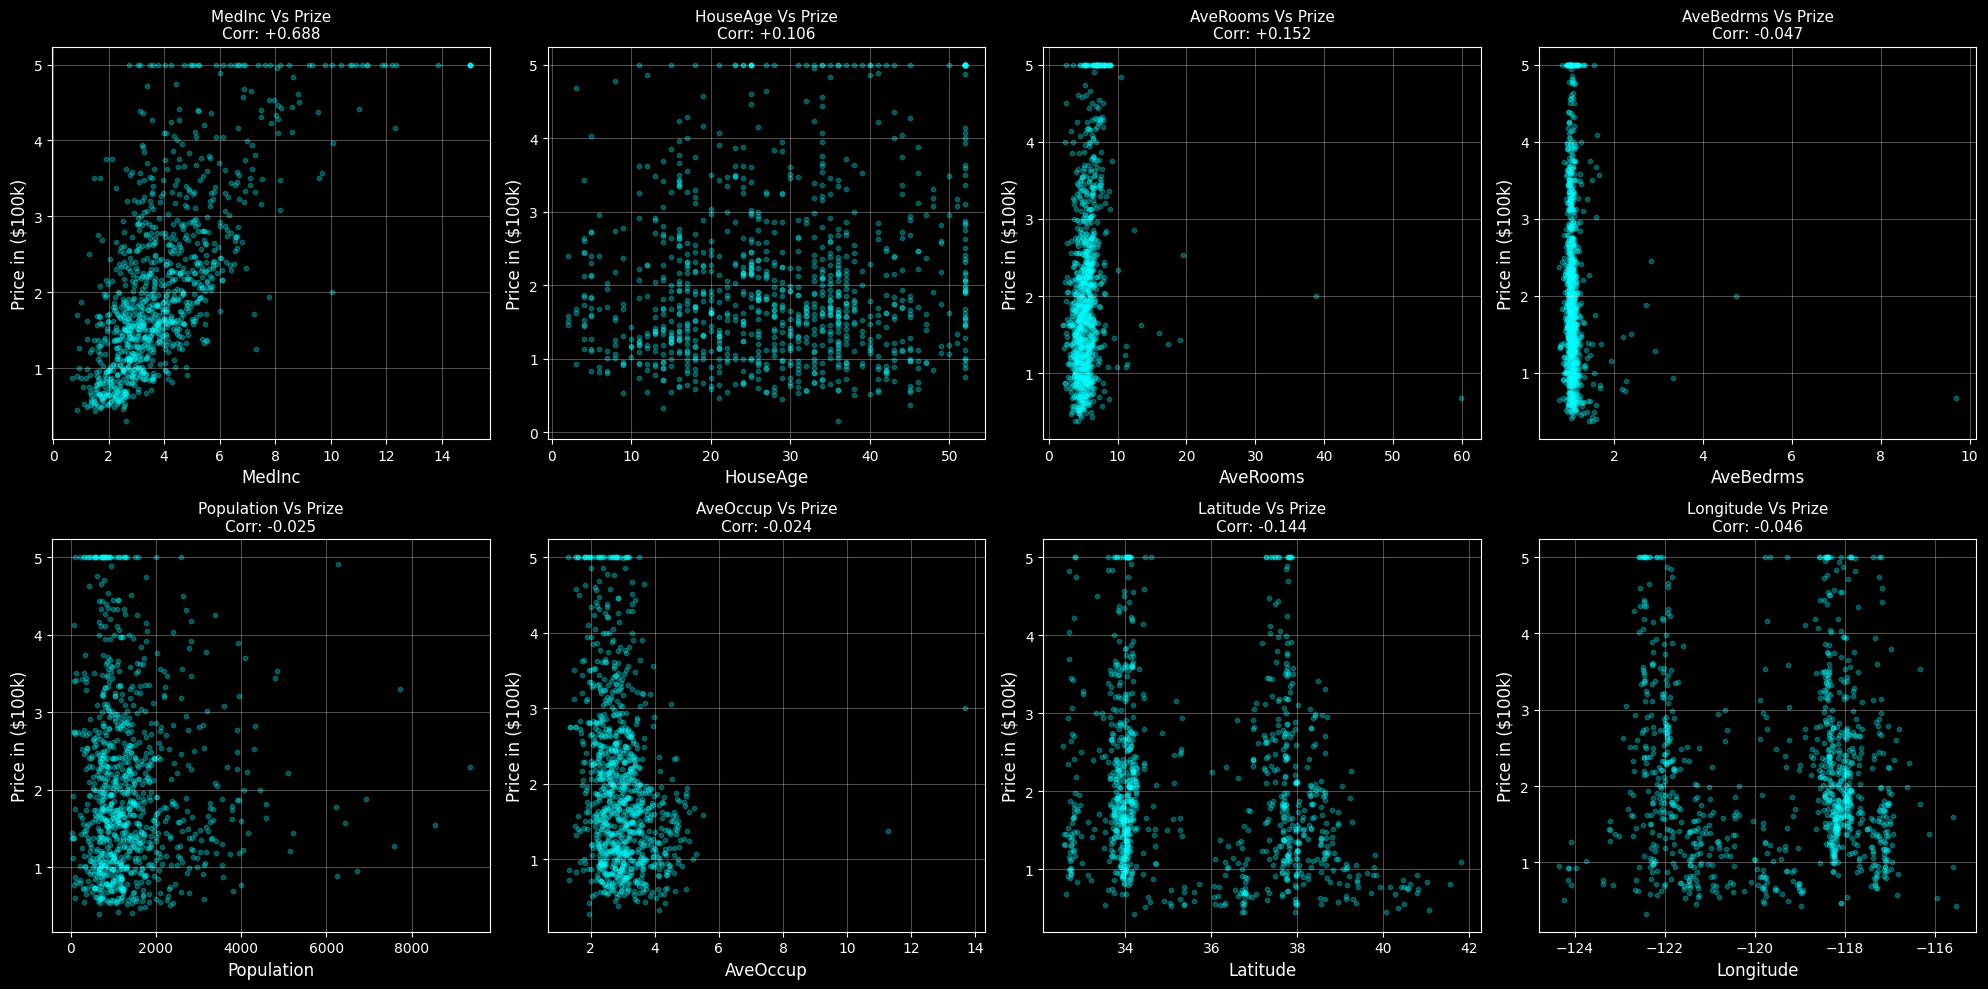

Notice how MedInc (median income) shows the clearest positive correlation .. also notice how things are looking different when dealing with real data!


In [7]:
# Here you're telling the library (Matplotlib) "Prepare a large drawing board for me, and divide it into two rows and four columns." This means you'll have eight squares ready for drawing. The `figsize` option specifies the overall size of the drawing board.
fig, axes = plt.subplots(2, 4, figsize=(20, 10))

# These squares are in the form of a grid (two rows and two columns). This function "unfolds" this grid and makes it one long queue (from 0 to 7) so that it is easy for us to go through them one by one inside the for loop.
axes = axes.flatten()

# Loop through the subplots (axes) and feature names simultaneously using zip().
# enumerate() keeps track of the current index 'i'.
# In each iteration:
# - 'i'    : The index (0, 1, 2, ...) used to fetch the feature's data and correlation value.
# - 'ax'   : The specific subplot (empty box) where we will draw the scatter plot.
# - 'name' : The name of the feature, used for the x-axis label and plot title.
for i, (ax, name) in enumerate(zip(axes, data.feature_names)):

    # This is a Python function that randomly selects numbers (like drawing lots). The function takes the following information within the parentheses:
    # Where does it select from? From the number we specified in the first step (meaning it selects numbers from 0 to 19,999).
    # How many numbers does it select? We specified 1000, so we're telling it to draw 1000 random numbers.
    # replace=False: This is a very important point! It means "no return" or "no duplication." If the code selects row 50, it will never select it again. This ensures that the 1000 resulting numbers will be completely different and that there are no duplicates.
    indices = np.random.choice(x.shape[0], 1000, replace=False)
    """
    Why do we do this in the first place?
    If you plot all 20,000 points on the graph, they'll all overlap, creating a solid "color patch" (a well-known data phenomenon called over plotting).
    You won't be able to see the direction of the points or clearly understand the relationship between them. This also makes the code very heavy and takes a long time to draw.
    When you take a random sample of just 1,000 points, the graph appears cleaner and lighter, while still giving you the same accurate picture of the relationship between the price and the bar.
    """

    ax.scatter(x[indices, i], y[indices], s=10, alpha=0.3, c='cyan')
    ax.set_xlabel(name, fontsize=12)
    ax.set_ylabel('Price in ($100k)', fontsize=12)
    ax.set_title(f'{name} Vs Prize\nCorr: {corr_list[i]:+.3f}', fontsize=11)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Notice how MedInc (median income) shows the clearest positive correlation .. also notice how things are looking different when dealing with real data!")

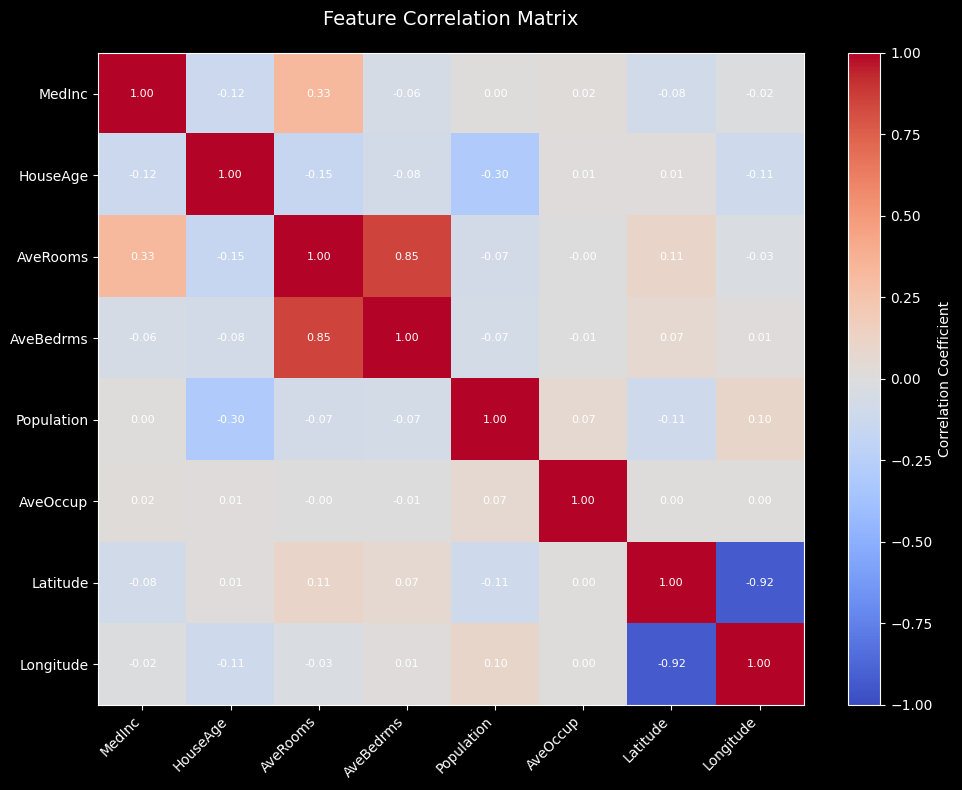


This helps us understand multicollinearity (covered in Lecture 7 but we briefly mentioned it in the first lecture 
 see how AveBedrms and AveRooms are correlated)


In [8]:
corr_matrix = np.corrcoef(x.T)

"""
The letter T stands for Transpose. Its function is to invert the data array X, meaning it converts rows to columns and columns to rows.

Why do we do this?

The np.corrcoef function in the NumPy library is programmed to always assume that rows are the variables (features) and columns are the samples.
However, in our data (and in machine learning in general), the opposite is true: the data is arranged so that columns are the variables (like income, house age, etc.).
So, in order for the function to understand our data correctly and calculate the correlation between the "columns," we must invert the array using X.T before giving it to the function.

https://numpy.org/doc/stable/reference/generated/numpy.corrcoef.html
x: array_like
A 1-D or 2-D array containing multiple variables and observations. Each row of x represents a variable, and each column a single observation of all those variables.
"""

plt.figure(figsize=(10, 8))

plt.imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1, aspect='auto')
plt.colorbar(label='Correlation Coefficient')

# Replace default numeric ticks on both axes with the actual feature names.
# For the x-axis, rotate the labels 45 degrees and align them to the right
# to prevent the text from overlapping and ensure readability.
plt.xticks(range(len(data.feature_names)), data.feature_names, rotation=45, ha='right')
plt.yticks(range(len(data.feature_names)), data.feature_names)
plt.title('Feature Correlation Matrix', fontsize=14, pad=20)

for i in range(len(data.feature_names)):
    for j in range(len(data.feature_names)):

        plt.text(j, i, f'{corr_matrix[i, j]:.2f}', ha='center', va='center', fontsize=8)

plt.tight_layout()
plt.show()
print("\nThis helps us understand multicollinearity (covered in Lecture 7 but we briefly mentioned it in the first lecture \n see how AveBedrms and AveRooms are correlated)")

**Key Insights:**
1. **MedInc** (median income) has the strongest correlation with price (+0.688)
2. **AveRooms** and **AveBedrms** are highly correlated (0.85) - makes sense!
3. Features with stronger correlations will give better predictions

---

## Part 3: Linear Regression from Scratch

Now let's build simple **linear regression**

We'll use **MedInc** (median income) as our feature since it has the strongest correlation.

**Remember:**
- Model: `ŷ = w * x + b`
- Cost function (MSE): `J = (1/2m) * Σ(ŷ - y)²`
- Gradient descent updates:
  - `w = w - η * (1/m) * Σ(ŷ - y) * x`
  - `b = b - η * (1/m) * Σ(ŷ - y)`

This is **NOT OOP-based** - just simple, clear code using **loops** and **vectorization** .. so that we see the functionality in a simpler way!

In [9]:
# Extract MedInc feature (feature 0)
x_medinc = x[:, 0]   # Median income
y_price = y          # House price

print(f'Total samples of feature: {len(x_medinc):,}')
print(f'The feature: {data.feature_names[0]}')
print('Target: median house value')

Total samples of feature: 20,640
The feature: MedInc
Target: median house value


In [10]:
np.random.seed(42)      # for reproducibility
# Initialize random wights
w = np.random.rand()
b = np.random.rand()

learning_rate = 0.01  # Learning rate .. Eta (η)
epochs = 1000         # Number of training iterations
n = len(x_medinc)     # Number of samples

# store cost history
cost_his = []

print(f'Initial w: {w:.4f}')
print(f'Initial b: {b:.4f}')
print(f'Learning rate: {learning_rate}')
print(f'Number of Epochs: {epochs}')
print('\nStarting Training....')


for epoch in range(epochs):

    y_pred = (w * x_medinc) + b

    error = y_pred - y_price

    grad_w = np.mean(error * x_medinc)
    grad_b = np.mean(error)

    w = w - learning_rate * grad_w
    b = b - learning_rate * grad_b

    cost = 0.5 * (np.mean(error ** 2))
    cost_his.append(cost)

    if (epoch + 1) % 100 == 0 or epoch == 0:
        print(f'Epoch = {epoch + 1:4d}: Cost = {cost:.4f}: w = {w:.4f}: b = {b:.4f}')

print('Training Completed...')
print(f'Final w: {w:.4f}')
print(f'Final b: {b:.4f}')
print(f'Final Cost: {cost_his[-1]:.4f}')

Initial w: 0.3745
Initial b: 0.9507
Learning rate: 0.01
Number of Epochs: 1000

Starting Training....
Epoch =    1: Cost = 0.4090: w = 0.3633: b = 0.9474
Epoch =  100: Cost = 0.3665: w = 0.3328: b = 0.8555
Epoch =  200: Cost = 0.3616: w = 0.3473: b = 0.7868
Epoch =  300: Cost = 0.3581: w = 0.3593: b = 0.7297
Epoch =  400: Cost = 0.3558: w = 0.3693: b = 0.6823
Epoch =  500: Cost = 0.3542: w = 0.3775: b = 0.6430
Epoch =  600: Cost = 0.3530: w = 0.3844: b = 0.6104
Epoch =  700: Cost = 0.3523: w = 0.3901: b = 0.5833
Epoch =  800: Cost = 0.3517: w = 0.3948: b = 0.5608
Epoch =  900: Cost = 0.3514: w = 0.3987: b = 0.5421
Epoch = 1000: Cost = 0.3511: w = 0.4020: b = 0.5266
Training Completed...
Final w: 0.4020
Final b: 0.5266
Final Cost: 0.3511


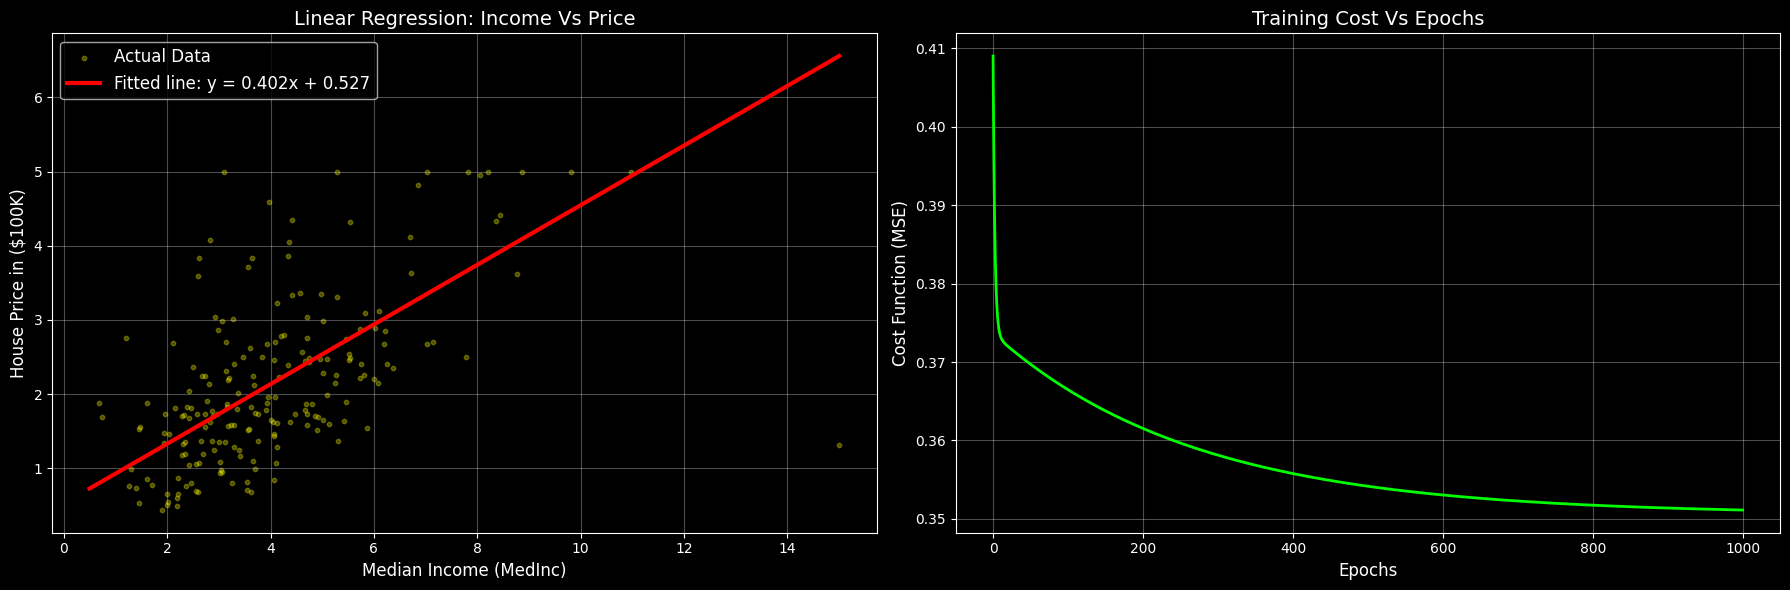


Notice how the cost decreases smoothly - this is gradient descent working!
The red line shows our model's predictions.


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

ax1 = axes[0]

indices = np.random.choice(n, 200, replace=False)

ax1.scatter(x_medinc[indices], y_price[indices], c='yellow', s=10, alpha=0.3, label='Actual Data')

x_line = np.linspace(x_medinc.min(), x_medinc.max(), 100)
y_line = (w * x_line) + b

ax1.plot(x_line, y_line, 'r-', linewidth=3, label=f'Fitted line: y = {w:.3f}x + {b:.3f}')
ax1.set_xlabel('Median Income (MedInc)', fontsize=12)
ax1.set_ylabel('House Price in ($100K)', fontsize=12)
ax1.set_title('Linear Regression: Income Vs Price', fontsize=14)
ax1.legend(fontsize=12)
ax1.grid(True, alpha=0.3)

ax2 = axes[1]

ax2.plot(cost_his, 'lime', linewidth=2)
ax2.set_xlabel('Epochs', fontsize=12)
ax2.set_ylabel('Cost Function (MSE)', fontsize=12)
ax2.set_title('Training Cost Vs Epochs', fontsize=14)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nNotice how the cost decreases smoothly - this is gradient descent working!")
print("The red line shows our model's predictions.")

In [12]:
test_income_data = np.array([2.0, 4.0, 6.0, 8.0])
test_pred = w * test_income_data + b

print('Prediction on new data:\n')

for new_income, new_output in zip(test_income_data, test_pred):
    print(f'Median Income: {new_income:.1f} → Predicted Price = ${new_output * 100000:,.0f}')

print(f"\nInterpretation: For every $10,000 increase in median income, ")
print(f"house price increases by ${w*10000:,.0f} on average.")

Prediction on new data:

Median Income: 2.0 → Predicted Price = $133,063
Median Income: 4.0 → Predicted Price = $213,464
Median Income: 6.0 → Predicted Price = $293,865
Median Income: 8.0 → Predicted Price = $374,267

Interpretation: For every $10,000 increase in median income, 
house price increases by $4,020 on average.


**What Just Happened?**

1. We initialized random `w` and `b` (weights and bias)
2. Used a **loop** (Week 1) to iterate through 1000 epochs
3. Used **vectorization** (Week 2) for fast gradient calculations
4. Updated weights using gradient descent (Lecture 3 formula)
5. Cost decreased - our model learned!

This is what happens inside important Machine and Deep learning libraries like TensorFlow and PyTorch!

---

## Part 4: Polynomial Regression

In **Lecture 3**, you learned about **polynomial regression** - fitting curves instead of straight lines.

**Linear:** `ŷ = w₁x + b`  
**Quadratic:** `ŷ = w₂x² + w₁x + b`  
**Cubic:** `ŷ = w₃x³ + w₂x² + w₁x + b`

Let's see if a polynomial fits better than a line!

In [13]:
# Ww will create polynomial features manually
def create_polynomial_features(x, degree):

    """
    Create polynomial features up to specified degree.

    Example: x = [1, 2], degree = 2
    """

    n = len(x)
    x_poly = np.zeros((n, degree + 1))

    for i in range(degree + 1):
        x_poly[:, i] = x ** i

    return x_poly

# Test the function
test_x = np.array([1, 2, 3])     # this is the column of x
poly_feature = create_polynomial_features(test_x, degree=2)

# the first column represents bias so always 1 and the second column is x [1 2 3] then x squared etc.
# note how the bias can be added as a feature with values of 1 because when we multiply that weight with that feature (ones) that would
# give just the bias so we now work with weights directly
print("Example: x = [1, 2, 3], degree = 2")
print("Polynomial features:")
print(poly_feature)
print("\nColumns: [1, x, x²]")

Example: x = [1, 2, 3], degree = 2
Polynomial features:
[[1. 1. 1.]
 [1. 2. 4.]
 [1. 3. 9.]]

Columns: [1, x, x²]


Train polynomial regression using sklearn (NOT from scratch! now we see how to call models from libraries)

In [14]:
def train_polynomial_regression_using_sklearn(x, y, degree, epochs=500):

    """
    Train polynomial regression using sklearn's PolynomialFeatures + LinearRegression.
    We track cost history for visualization purposes.
    """

    poly = PolynomialFeatures(degree=degree, include_bias=True)
    x_poly = poly.fit_transform(x.reshape(-1, 1))
    # x.reshape(-1, 1) putting data in samples and one feature ..
    # fit_transform does both the training (fit) and then applies that to data (transform)
    # this function is similar to our function in the previous cell: create_polynomial_features .. so it gives the polynomial features

    # Train using sklearn's LinearRegression
    model = LinearRegression(fit_intercept=False)        # bias already in poly features so we added the ones for the bias so we need that to be false otherwise it would add it again here
    model.fit(x_poly, y)

    y_pred_poly = model.predict(x_poly)

    # Get predictions and calculate MSE
    mse = 0.5 * (np.mean((y_pred_poly - y) ** 2))

    costs = [mse] * epochs

    return model.coef_, costs, x_poly

print("Polynomial regression function ready (using sklearn)!")

Polynomial regression function ready (using sklearn)!


In [15]:
# Train models with different polynomial degrees using sklearn
degrees = [1, 2, 3, 5]

# Initialize an empty dictionary to archive the results of each model.
# This prevents the loop from overwriting previous results and allows us
# to save and compare the weights and costs for every polynomial degree later.
models = {}

print('Train models with different polynomial degrees using sklearn...')

for degree in degrees:
    weights, cost, _ = train_polynomial_regression_using_sklearn(x_medinc, y_price, degree=degree, epochs=500)

    # Store the trained weights and cost history for the current degree in the dictionary
    models[degree] = (weights, cost)
    print(f'Degree: {degree}: Final MSE: {cost[-1]:.4f}')

print("\nAll models trained using sklearn!")

Train models with different polynomial degrees using sklearn...
Degree: 1: Final MSE: 0.3506
Degree: 2: Final MSE: 0.3475
Degree: 3: Final MSE: 0.3421
Degree: 5: Final MSE: 0.3420

All models trained using sklearn!


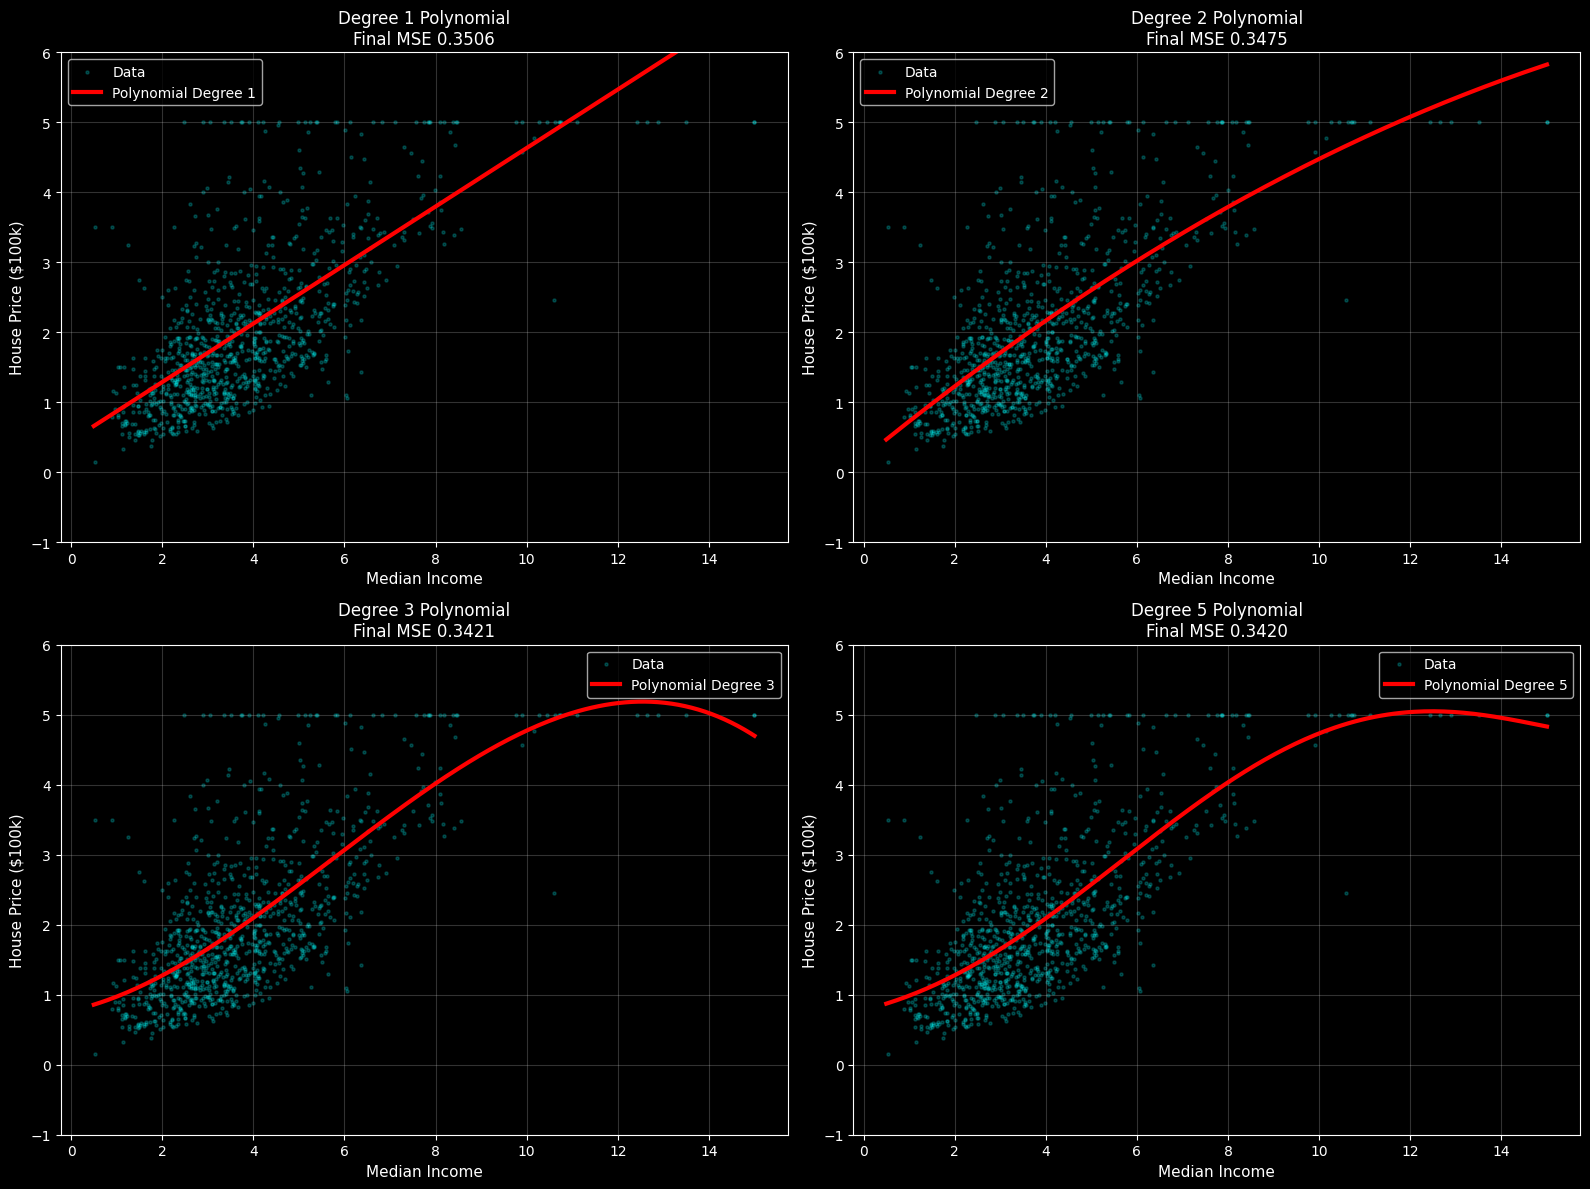

Notice: Higher degrees fit the data better BUT become wiggly at the edges!
This could be the beginning of OVERFITTING


In [16]:
# Visualize polynomial fits
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

# Sample data for plotting
indices = np.random.choice(len(x_medinc), 1000, replace=False)
x_plot = np.linspace(x_medinc.min(), x_medinc.max(), 200)

for ax, degree in zip(axes, degrees):

    # plot data
    ax.scatter(x_medinc[indices], y_price[indices], alpha=0.2, s=5, c='cyan', label='Data')

    # plot polynomial fit using sklearn
    weights = models[degree][0]
    poly = PolynomialFeatures(degree=degree, include_bias=True)
    x_plot_poly = poly.fit_transform(x_plot.reshape(-1, 1))
    y_plot = x_plot_poly @ weights

    ax.plot(x_plot, y_plot, 'r-', linewidth=3, label=f'Polynomial Degree {degree}')
    ax.set_xlabel('Median Income', fontsize=11)
    ax.set_ylabel('House Price ($100k)', fontsize=11)
    ax.set_title(f'Degree {degree} Polynomial\nFinal MSE {models[degree][1][-1]:.4f}', fontsize=12)
    ax.legend()
    ax.grid(True, alpha=0.2)
    ax.set_ylim([-1, 6])

plt.tight_layout()
plt.show()

print("Notice: Higher degrees fit the data better BUT become wiggly at the edges!")
print("This could be the beginning of OVERFITTING")

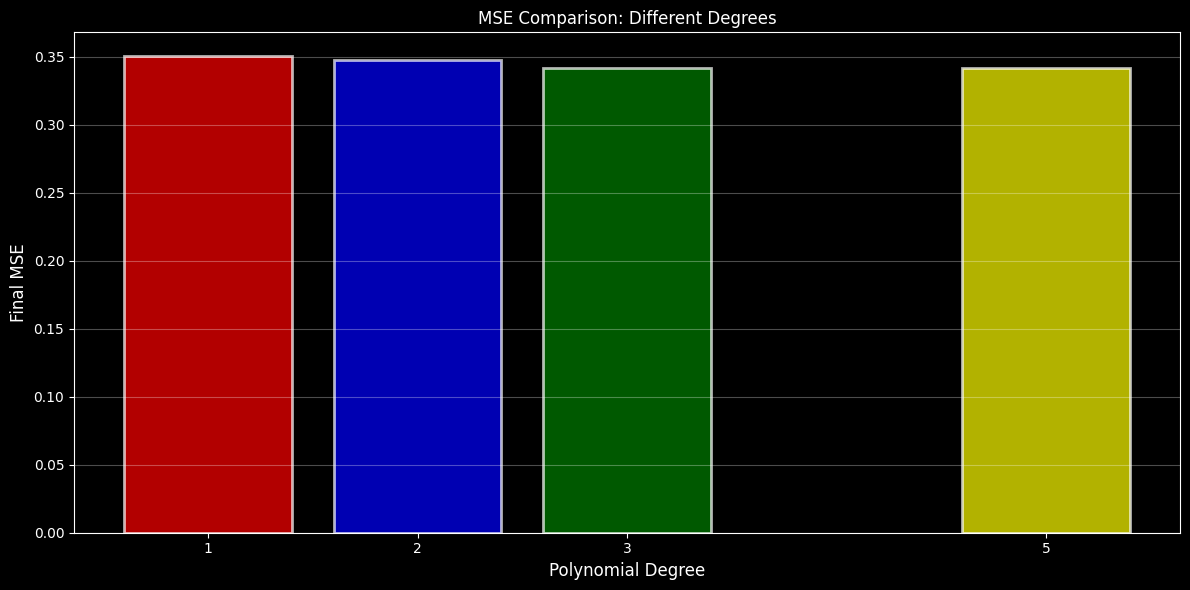

Higher degree polynomials achieve lower training error.
But this doesn't always mean better generalization on new samples!

MSE values:
Degree 1: 0.3506
Degree 2: 0.3475
Degree 3: 0.3421
Degree 5: 0.3420


In [17]:
# Compare final MSE values (not convergence, since sklearn solves instantly)
degrees_list = list(degrees)
mse_values = [models[degree][1][-1] for degree in degrees]

plt.figure(figsize=(12, 6))

plt.bar(degrees_list, mse_values, color=['red', 'blue', 'green', 'yellow'], alpha=0.7, edgecolor='white', linewidth=2)
plt.xlabel('Polynomial Degree', fontsize=12)
plt.ylabel('Final MSE', fontsize=12)
plt.title('MSE Comparison: Different Degrees')
plt.xticks(degrees_list)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

print("Higher degree polynomials achieve lower training error.")
print("But this doesn't always mean better generalization on new samples!")
print(f"\nMSE values:")

for degree in degrees:
    print(f'Degree {degree}: {models[degree][1][-1]:.4f}')

**Key Insights:**

1. **Degree 1** (linear) is simple but has higher error
2. **Degree 2-3** provide a good balance
3. **Degree 5** has lowest training error BUT notice the wiggles!
4. This demonstrates the **bias-variance tradeoff** a little bit (more on that in Lecture 8)

**When to use polynomial regression?**
- When relationship is clearly non-linear
- Be careful not to overfit with high degrees

---

## Part 5: Comparing Optimizers


**Types of Gradient Descent:**
1. **Batch GD** - Uses ALL data at once (what we did above)
2. **Stochastic GD (SGD)** - Uses ONE sample at a time
3. **Mini-batch GD** - Uses small batches of samples

**Advanced Optimizers:**

4. **Momentum**
5. **RMSprop**
6. **Adam**


In [18]:
n_samples = 5000

# Extracting a single column (index 0) from a NumPy array returns a flat 1D array (e.g., [a, b, c]).
# However, Scikit-Learn models strictly require the feature data (X) to be a 2D array (a table with rows and columns).
# We use reshape(-1, 1) to convert this 1D array into a 2D column vector:
# - The '1' tells Python to arrange the data into exactly 1 column.
# - The '-1' is a placeholder that tells Python to automatically calculate the number of rows based on the data size.
# Resulting shape changes from [a, b, c] to [[a], [b], [c]] which Scikit-Learn accepts.
x_train = x[:n_samples, 0].reshape(-1, 1)
y_train = y[:n_samples]

print(f"Training with {n_samples} samples")
print(f"Feature: {data.feature_names[0]}")
print(f"\nWe'll compare 6 different optimizers!")

Training with 5000 samples
Feature: MedInc

We'll compare 6 different optimizers!


### 1. Batch Gradient Descent (from scratch)

In [19]:
def batch_gradient_decent(x, y, learning_rate=0.01, epochs=200):

    """
    Standard batch gradient descent.
    Uses ALL samples in each iteration.
    """

    n = len(x)
    np.random.seed(42)
    w = 0.5
    b = 0.5

    cost_history = []
    w_history = [w]
    b_history = [b]

    for epoch in range(epochs):

        # predictions
        # X.flatten() converts x to 1d .. note how we change the implementation slightly so that you familiaris yourself with different functions
        y_pred = w * x.flatten() + b

        # Different ways of implementing the same thing
        error = y_pred - y

        # Gradient all samples
        grad_w = np.mean(error * x.flatten())
        grad_b = np.mean(error)

        # Update
        w = w - learning_rate * grad_w
        b = b - learning_rate * grad_b

        # Cost
        cost = 0.5 * np.mean(error ** 2)
        cost_history.append(cost)
        w_history.append(w)
        b_history.append(b)
    # Return full history for visualization
    return cost_history, np.array(w_history), np.array(b_history)

print("Batch Gradient Descent function ready!")

Batch Gradient Descent function ready!


### By Using PyTorch

In [20]:
# Train all optimizers using PyTorch .. note how we do that with PyTorch and how we put our data in specific format for PyTorch
# it may seem a lot for now but when the models are complicated PyTorch is the go to.
# don't worry if you don't know all the steps right now because we will come to them many times with other models
# Convert data to PyTorch tensors
x_train_torch = torch.FloatTensor(x_train)
y_train_torch = torch.FloatTensor(y_train)

# We set the number of turns (Epochs) at 200 turns.
max_iter = 200

# We created an empty dictionary so that we can store the error rate of each training method and compare them together at the end.
results = {}

print('Training optimizer with PyTorch.....\n')

# Function to create and initialize model with same weights
def create_model():

    # Fix seed for reproducible initialization
    torch.manual_seed(42)

    # Create a simple linear model: y = w * x + b
    # This line creates a linear regression model! The (1, 1) means: "I'll give you one feature (the income), and I want you to give me one number (the price)." This line automatically constructs the equation y = wx + b.
    model = nn.Linear(1, 1)

    # Initialize with same values for fair comparison
    # PyTorch normally sets random numbers for weight and bias. But because we want to compare it with the previous manual code (where we started with w=0.5 and b=0.5),
    # it forces PyTorch to start with exactly the same numbers (0.5) so that the comparison is 100% fair and no model starts from a better point than the other.
    nn.init.constant_(model.weight, 0.5)
    nn.init.constant_(model.bias, 0.5)

    return model


# PyTorch has a built-in function that calculates the MSE, but this built-in function doesn't multiply by 0.5.
# Since our manual code used to multiply by 0.5 (to simplify calculating differentials and derivatives), the instructor created this function specifically to calculate the error using our old method down to the millimeter.
def custom_mse_loss(pred_out, actual_target):
    return 0.5 * torch.mean((pred_out - actual_target) ** 2)

Training optimizer with PyTorch.....



#### 1. Batch Gradient Descent (from scratch - reference)

In [21]:
print("1. Batch Gradient Descent (from scratch)...")
costs_batch, w_batch, b_batch = batch_gradient_decent(x_train, y_train, learning_rate=0.01, epochs=max_iter)

w_batch_3d = w_batch
b_batch_3d = b_batch
results['Batch GD'] = costs_batch
print(f'   Final MSE: {costs_batch[-1]:.4f}')

1. Batch Gradient Descent (from scratch)...
   Final MSE: 0.3159


#### 2. SGD (Stochastic Gradient Descent)

In [22]:
print("\n2. Stochastic Gradient Descent (SGD)...")
# This is our "mechanical" tool. Instead of writing the update equation ourselves w = w - lr * grad, here we give this mechanical tool the model weights (model_sgd.parameters()) and the learning speed (lr=0.01), and it will take care of the rest.
model_sgd = create_model()
optimizer_sgd = optim.SGD(model_sgd.parameters(), lr=0.01)  # Use PyTorch's built-in SGD optimizer
cost_sgd = []
w_history_sgd = [0.5]
b_history_sgd = [0.5]

for epoch in range(max_iter):
    # not how we have the main structure of applying the weights then computing gradients then updating the weights
    # but now we are doing this with PyTorch so we are not manually calculating them
    optimizer_sgd.zero_grad()
    outputs = model_sgd(x_train_torch)                          # Forward pass: predict prices from input feature
    loss = custom_mse_loss(outputs.squeeze(), y_train_torch)    # Compute loss (0.5 * MSE)
    loss.backward()                                             # Update parameters using gradients
    optimizer_sgd.step()                                        # Update parameters using gradients

    # Store loss and parameters for analysis
    cost_sgd.append(loss.item())
    w_history_sgd.append(model_sgd.weight.item())
    b_history_sgd.append(model_sgd.bias.item())

results['SGD'] = cost_sgd
print(f'    Final MSE: {cost_sgd[-1]:.4f}')


2. Stochastic Gradient Descent (SGD)...
    Final MSE: 0.3159


#### 3. SGD with Momentum

In [23]:
print("\n3. SGD with Momentum...")

model_momentum = create_model()
optimizer_momentum = optim.SGD(model_momentum.parameters(), lr=0.01, momentum=0.9) # Use PyTorch's built-in SGD with Momentum optimizer
costs_momentum = []
w_history_momentum = [0.5]
b_history_momentum = [0.5]

for epoch in range(max_iter):

  optimizer_momentum.zero_grad()
  outputs = model_momentum(x_train_torch)
  loss = custom_mse_loss(outputs.squeeze(), y_train_torch)
  loss.backward()
  optimizer_momentum.step()
  costs_momentum.append(loss.item())
  w_history_momentum.append(model_momentum.weight.item())
  b_history_momentum.append(model_momentum.bias.item())

results['Momentum'] = costs_momentum
print(f'  Final MSE: {costs_momentum[-1]:.4f}')



3. SGD with Momentum...
  Final MSE: 0.3157


#### 4. RMSprop

In [24]:
print("\n4. RMSprop...")

model_rmsprop = create_model()
optimizer_rmsprop = optim.RMSprop(model_rmsprop.parameters(), lr=0.01) # Use PyTorch's built-in RMSprop optimizer
costs_rmsprop = []
w_history_rmsprop = [0.5]
b_history_rmsprop = [0.5]

for epoch in range(max_iter):

  optimizer_rmsprop.zero_grad()
  outputs = model_rmsprop(x_train_torch)
  loss = custom_mse_loss(outputs.squeeze(), y_train_torch)
  loss.backward()
  optimizer_rmsprop.step()
  costs_rmsprop.append(loss.item())
  w_history_rmsprop.append(model_rmsprop.weight.item())
  b_history_rmsprop.append(model_rmsprop.bias.item())

results['RMSprop'] = costs_rmsprop
print(f'  Final MSE: {costs_rmsprop[-1]:.4f}')


4. RMSprop...
  Final MSE: 0.3207


#### 5. Adam

In [25]:
print("\n4. Adam...")

model_adam = create_model()
optimizer_adam = optim.Adam(model_adam.parameters(), lr=0.01) # Use PyTorch's built-in RMSprop optimizer
costs_adam = []
w_history_adam = [0.5]
b_history_adam = [0.5]

for epoch in range(max_iter):

  optimizer_adam.zero_grad()
  outputs = model_adam(x_train_torch)
  loss = custom_mse_loss(outputs.squeeze(), y_train_torch)
  loss.backward()
  optimizer_adam.step()
  costs_adam.append(loss.item())
  w_history_adam.append(model_adam.weight.item())
  b_history_adam.append(model_adam.bias.item())

results['Adam'] = costs_adam
print(f'  Final MSE: {costs_adam[-1]:.4f}')


4. Adam...
  Final MSE: 0.3157


#### 6. AdamW (Adam with weight decay (will talk about it later in lecture 8 but i want you to see it here as well))

In [26]:
print("\n4. AdamW...")

model_adamw = create_model()
optimizer_adamw = optim.Adam(model_adamw.parameters(), lr=0.01) # Use PyTorch's built-in RMSprop optimizer
costs_adamw = []
w_history_adamw = [0.5]
b_history_adamw = [0.5]

for epoch in range(max_iter):

  optimizer_adamw.zero_grad()
  outputs = model_adamw(x_train_torch)
  loss = custom_mse_loss(outputs.squeeze(), y_train_torch)
  loss.backward()
  optimizer_adamw.step()
  costs_adamw.append(loss.item())
  w_history_adamw.append(model_adamw.weight.item())
  b_history_adamw.append(model_adamw.bias.item())

results['AdamW'] = costs_adamw
print(f'  Final MSE: {costs_adamw[-1]:.4f}')


4. AdamW...
  Final MSE: 0.3157


In [27]:
print("\n" + "="*50)
print("All optimizers trained with PyTorch!")
print("="*50)
print("\nNote: All optimizers start from the same initialization (w=0.5, b=0.5)")
print("This ensures a fair comparison of convergence behavior.")


All optimizers trained with PyTorch!

Note: All optimizers start from the same initialization (w=0.5, b=0.5)
This ensures a fair comparison of convergence behavior.


Store weight histories for 3D visualization


In [28]:
weight_histories = {
    'Batch_GD': (w_batch_3d, b_batch_3d) if 'w_batch_3d' in locals() else (None, None),
    'SGD': (np.array(w_history_sgd), np.array(b_history_sgd)),
    'Momentum' : (np.array(w_history_momentum), np.array(b_history_momentum)),
    'RMSprop' : (np.array(w_history_rmsprop), np.array(b_history_rmsprop)),
    'Adam' : (np.array(w_history_adam), np.array(b_history_adam)),
    'AdamW' : (np.array(w_history_adamw), np.array(b_history_adamw))

}

### 3D Visualization: Loss Surface with ALL Optimizer Paths

Creating 3D loss surface visualization...


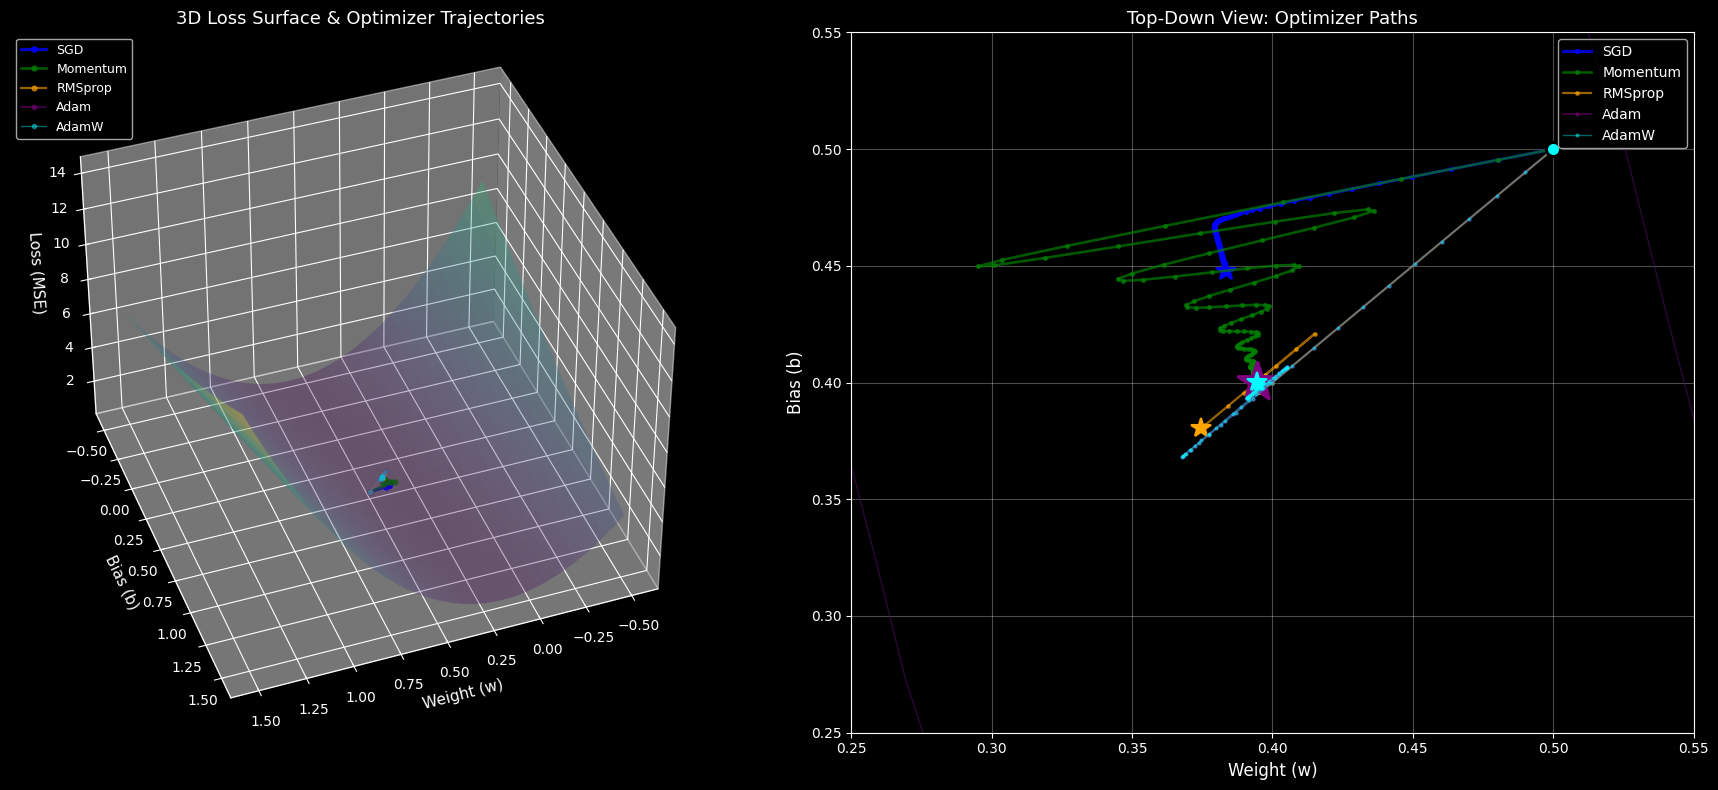

In [29]:
# 3D Visualization: Loss Surface with ALL Optimizer Paths
# You don't have to go through all the steps of the code because this is more about understanding the behaviour of each optimiser
# rather than coding .. because in practice we don't always visualise that .. imagine if we even just have 10 features!
print("Creating 3D loss surface visualization...")

fig = plt.figure(figsize=(18, 8))

# Subplot 1: 3D Loss surface with paths
ax1 = fig.add_subplot(121, projection='3d')

# Create grid for loss surface
w_range = np.linspace(-0.5, 1.5, 40)
b_range = np.linspace(-0.5, 1.5, 40)
W, B = np.meshgrid(w_range, b_range)

# Calculate loss for each point on the grid
Z = np.zeros_like(W)
X_flat = x_train.flatten()
for i in range(W.shape[0]):
    for j in range(W.shape[1]):
        y_pred = W[i, j] * X_flat + B[i, j]
        Z[i, j] = 0.5 * np.mean((y_pred - y_train)**2)

# Plot surface
surf = ax1.plot_surface(W, B, Z, alpha=0.3, cmap='viridis', edgecolor='none')

# Plot optimizer paths
colors_3d = ['red', 'blue', 'green', 'orange', 'purple', 'cyan']
optimizer_names = ['Batch GD', 'SGD', 'Momentum', 'RMSprop', 'Adam', 'AdamW']

for i, (name, color) in enumerate(zip(optimizer_names, colors_3d)):
    if name in weight_histories and weight_histories[name][0] is not None:
        w_hist, b_hist = weight_histories[name]

        # Calculate loss values for the path
        z_hist = []
        for w, b in zip(w_hist, b_hist):
            y_pred = w * X_flat + b
            z = 0.5 * np.mean((y_pred - y_train)**2)
            z_hist.append(z)

        # Plot path
        step = max(1, len(w_hist) // 20) # showing that with 20 points across the path
        linewidth = 2.5 - 0.3 * i         # thinner for later optimizers
        markersize = 4 - 0.2 * i          # smaller markers for later ones
        alpha = 0.9 - 0.1 * i             # more transparent as i increases

        ax1.plot(w_hist[::step], b_hist[::step], z_hist[::step],
                 color=color, linewidth=linewidth, marker='o', markersize=markersize,
                 label=name, alpha=alpha)



ax1.set_xlabel('Weight (w)', fontsize=11)
ax1.set_ylabel('Bias (b)', fontsize=11)
ax1.set_zlabel('Loss (MSE)', fontsize=11)
ax1.set_title('3D Loss Surface & Optimizer Trajectories', fontsize=13)
ax1.legend(fontsize=9, loc='upper left')
ax1.view_init(elev=40, azim=70)

# Subplot 2: Top-down contour view
ax2 = fig.add_subplot(122)

# Create contour plot
contour = ax2.contour(W, B, Z, levels=30, cmap='viridis', alpha=0.6, linewidths=1)
ax2.clabel(contour, inline=True, fontsize=8, fmt='%.2f')


for i, (name, color) in enumerate(zip(optimizer_names, colors_3d)):
    if name in weight_histories and weight_histories[name][0] is not None:
        w_hist, b_hist = weight_histories[name]

        linewidth = 2.5 - 0.3 * i
        markersize = 3 - 0.2 * i
        alpha = 0.9 - 0.1 * i

        # Plot full path
        ax2.plot(w_hist, b_hist, color=color, linewidth=linewidth,
                 marker='o', markersize=markersize, label=name, alpha=alpha)

        # Mark start and end
        if name != 'Batch GD' and name != 'Adam':
            ax2.plot(w_hist[0], b_hist[0], 'ko', markersize=10,
                    markerfacecolor=color, markeredgewidth=2)

        if name == 'Batch GD' or name == 'Adam':
            ax2.plot(w_hist[-1], b_hist[-1], color=color, marker='*',
                    markersize=30, markerfacecolor=color, markeredgewidth=2)
        else:
            ax2.plot(w_hist[-1], b_hist[-1], color=color, marker='*',
                    markersize=15, markeredgecolor=color, markeredgewidth=1.5)





ax2.set_xlabel('Weight (w)', fontsize=12)
ax2.set_ylabel('Bias (b)', fontsize=12)
ax2.set_title('Top-Down View: Optimizer Paths', fontsize=13)
ax2.legend(fontsize=10, loc='upper right')
ax2.grid(True, alpha=0.3)
#ax2.set_xlim([w_range[0], w_range[-1]])
#ax2.set_ylim([b_range[0], b_range[-1]])

ax2.set_xlim([0.25, 0.55])
ax2.set_ylim([0.25, 0.55])


plt.tight_layout()
plt.show()


Visualize optimizer comparison

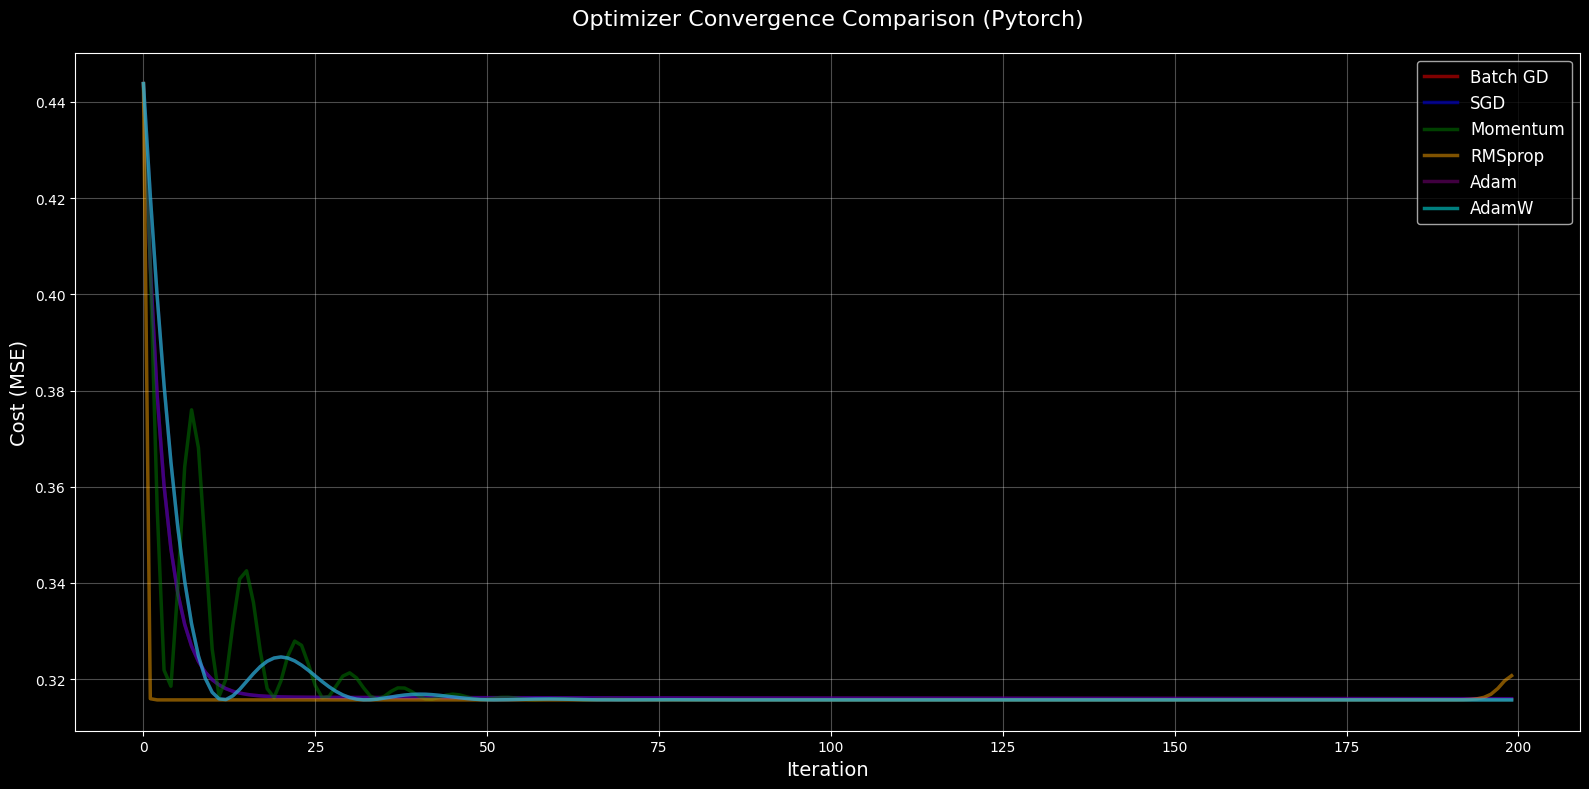

In [33]:
plt.figure(figsize=(16, 8))

colors = ['red', 'blue', 'green', 'orange', 'purple', 'cyan']
for (name, costs), color in zip(results.items(), colors):
  plt.plot(costs, linewidth=2.5, label=name, color=color, alpha=0.5)


plt.xlabel('Iteration', fontsize=14)
plt.ylabel('Cost (MSE)', fontsize=14)
plt.title('Optimizer Convergence Comparison (Pytorch)', fontsize=16, pad=20)
plt.legend(fontsize=12, loc='upper right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

These are ACTUAL PyTorch optimizers - the same ones used in production deep learning!

---

## Part 6: sklearn LinearRegression


Let's compare our from-scratch version with sklearn!

In [35]:
# Using sklearn's Linear Regression
# Trian the model
sklearn_model = LinearRegression()
sklearn_model.fit(x_train, y_train)

w_sklearn = sklearn_model.coef_[0]
b_sklearn = sklearn_model.intercept_

print("sklearn LinearRegression trained!")
print(f"\nLearned parameters:")
print(f'Weight = {w_sklearn}')
print(f'Bias   = {b_sklearn}')

sklearn LinearRegression trained!

Learned parameters:
Weight = 0.39430555405904016
Bias   = 0.4001017259602566


In [36]:
# Compare with our from-scratch model (from Part 5)
print("\n" + "="*50)
print("COMPARISON: From-Scratch vs sklearn")
print("="*50)

# Our from-scratch model (BatchGD)
# w_batch & b_batch are scalars from line 29
print(f'From-scratch (Batch GD)')
print(f'  Final MSE: {costs_batch[-1]}')

# sklearn model
y_sklearn_pred = sklearn_model.predict(x_train)
mse_sklearn = 0.5 * np.mean((y_sklearn_pred - y_train) ** 2)

print(f"\nsklearn LinearRegression:")
print(f"  Final MSE:  {mse_sklearn}")

print(f"\nDifference:")
print(f"  MSE difference:    {abs(costs_batch[-1] - mse_sklearn)}")

print("\nConclusion: Both methods produce nearly identical results!")
print("sklearn uses the Normal Equation (instant, no iteration needed).")


COMPARISON: From-Scratch vs sklearn
From-scratch (Batch GD)
  Final MSE: 0.31592672361645446

sklearn LinearRegression:
  Final MSE:  0.3156783243855424

Difference:
  MSE difference:    0.0002483992309120775

Conclusion: Both methods produce nearly identical results!
sklearn uses the Normal Equation (instant, no iteration needed).
